In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# Load latent demand and sort chronologically for each station
df = pd.read_csv("latent_demand.csv").sort_values(['station', 'datetime'])

In [ ]:
df[:3]

,datetime,station,demande_latente
0,2025-11-10 00:00:00,0,-0.276960
1,2025-11-10 00:20:00,0,-0.216140
2,2025-11-10 00:40:00,0,0.059473


In [ ]:
# Here we would need the station capacity (can be adapted)
capacity = 20

Build a 3D tensor: station × day × time-of-day

In [ ]:
# number of time slots per day (20-minute intervals)
N_per_day = 24 * 3

# number of days
N_days = 7

# number of stations (for reshaping)
N_stations = 10

# time grid (extra step for day-to-day linking)
times = np.arange(N_per_day + 1)

In [ ]:
# number of stations actually present in the dataset
N_stations = df['station'].nunique()

# reshape latent demand into a 3D tensor
# shape: (station, day, time)
latent_demand = df['demande_latente'].values.reshape(
    N_stations,
    N_days,
    N_per_day
)

Trajectory simulator

A trajectory is the evolution of station inventory during a day
if the station starts the day at level day_start.

Trajectories are computed by the simulator:

demand is accumulated over time

inventory is clipped to the feasible interval [0, capacity]

In [ ]:
def simulate_trajectory(day_starts):

    # "day_link" allows reconnecting trajectories
    # from one day to the next (J → J+1)
    day_link = 1

    inventory = np.zeros((N_stations, N_days, N_per_day + day_link))

    # iterate over time slots (last axis)
    for t in range(N_per_day + day_link):

        if t == 0:
            # initial condition
            inventory[:, :, t] = np.clip(day_starts[:, :], 0, capacity)

        else:
            # previous inventory + current demand
            val = inventory[:, :, t-1] + latent_demand[:, :, t-1]

            # clip to station bounds
            inventory[:, :, t] = np.clip(val, 0, capacity)

    return inventory

Compute trajectory envelopes

We construct xMIN and xMAX, the envelope of all trajectories.

xMIN: trajectory starting completely empty

xMAX: trajectory starting completely full

In [ ]:
startMIN = np.zeros((N_stations, N_days))
startMAX = np.full((N_stations, N_days), capacity)

In [ ]:
xMIN = simulate_trajectory(startMIN)
xMAX = simulate_trajectory(startMAX)

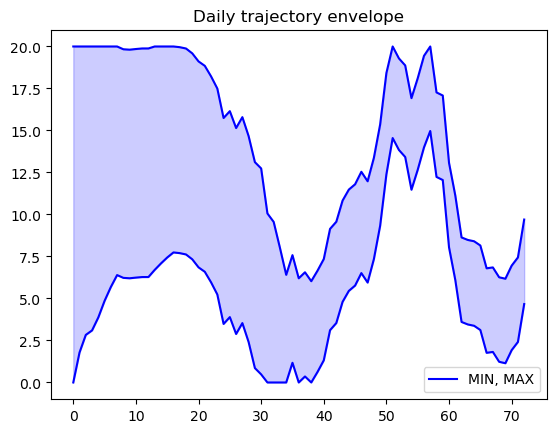

In [ ]:
# Example visualization of the envelope
s = 3
d = 2

plt.plot(xMIN[s, d], color="blue", label="MIN, MAX")
plt.plot(xMAX[s, d], color="blue")

plt.fill_between(times, xMIN[s, d], xMAX[s, d],
                 color="blue", alpha=0.2)

plt.legend()
plt.title("Daily trajectory envelope")
plt.show()

Critical time

If demand amplitude is large, the MIN and MAX trajectories may intersect.

This happens at a critical time tc.

In [ ]:
# detect the first time where the two trajectories coincide
tc = np.argmax(xMIN == xMAX, axis=-1)

# convention: if no intersection occurs
# we set tc = N_per_day
tc[tc == 0] = N_per_day

Exemple

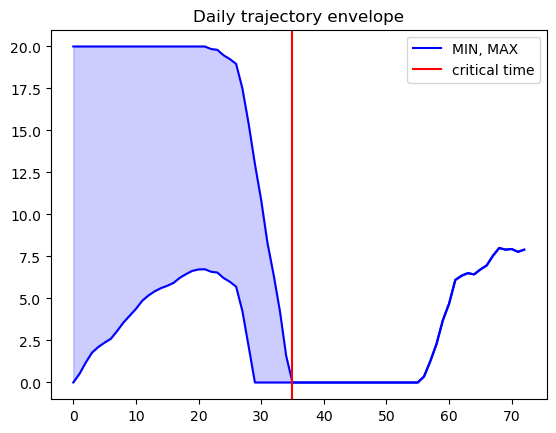

In [ ]:
s = 8
d = 1

plt.plot(xMIN[s, d], color="blue", label="MIN, MAX")
plt.plot(xMAX[s, d], color="blue")

plt.axvline(x=tc[s, d], color="red", label="critical time")

plt.fill_between(times, xMIN[s, d], xMAX[s, d],
                 color="blue", alpha=0.2)

plt.legend()
plt.title("Daily trajectory envelope")
plt.show()

Balanced trajectories

A trajectory is balanced if it does not saturate before the critical time.

This is the best situation we can hope for.

We also compute the envelope xmin, xmax of balanced trajectories.

In practice, xmin and xmax are very often identical,
meaning that only one balanced trajectory exists.

In [ ]:
# cumulative demand over time
cumulative_demand = np.cumsum(latent_demand, axis=-1)

# include initial zero to match trajectory indexing
cumulative_demand = np.concatenate(
    [np.zeros((*cumulative_demand.shape[:2], 1)), cumulative_demand],
    axis=-1
)

In [ ]:
# target initial offsets ensuring saturation exactly at tc

target_EMPTY = np.take_along_axis(
    xMIN - cumulative_demand,
    tc[:, :, None],
    axis=-1
)

target_FULL = np.take_along_axis(
    xMAX - cumulative_demand,
    tc[:, :, None],
    axis=-1
)

xmin = cumulative_demand + target_EMPTY
xmax = cumulative_demand + target_FULL

# after the critical time the envelopes collapse
after_tc = times[None, None, :] >= tc[:, :, None]

xmin[after_tc] = xMIN[after_tc]
xmax[after_tc] = xMAX[after_tc]  # xMIN = xMAX after tc

Export

In [ ]:
save_outputs = False
if save_outputs:
    import os

    dir = "results/"
    os.makedirs(dir, exist_ok=True)
    for data, d_name in zip([xMIN, xMAX, xmin, xmax], ["xmin_out", "xmax_out", "xmin_in", "xmax_in"]):
        np.save(dir + d_name + ".npy", data)

Now we can visualize results:

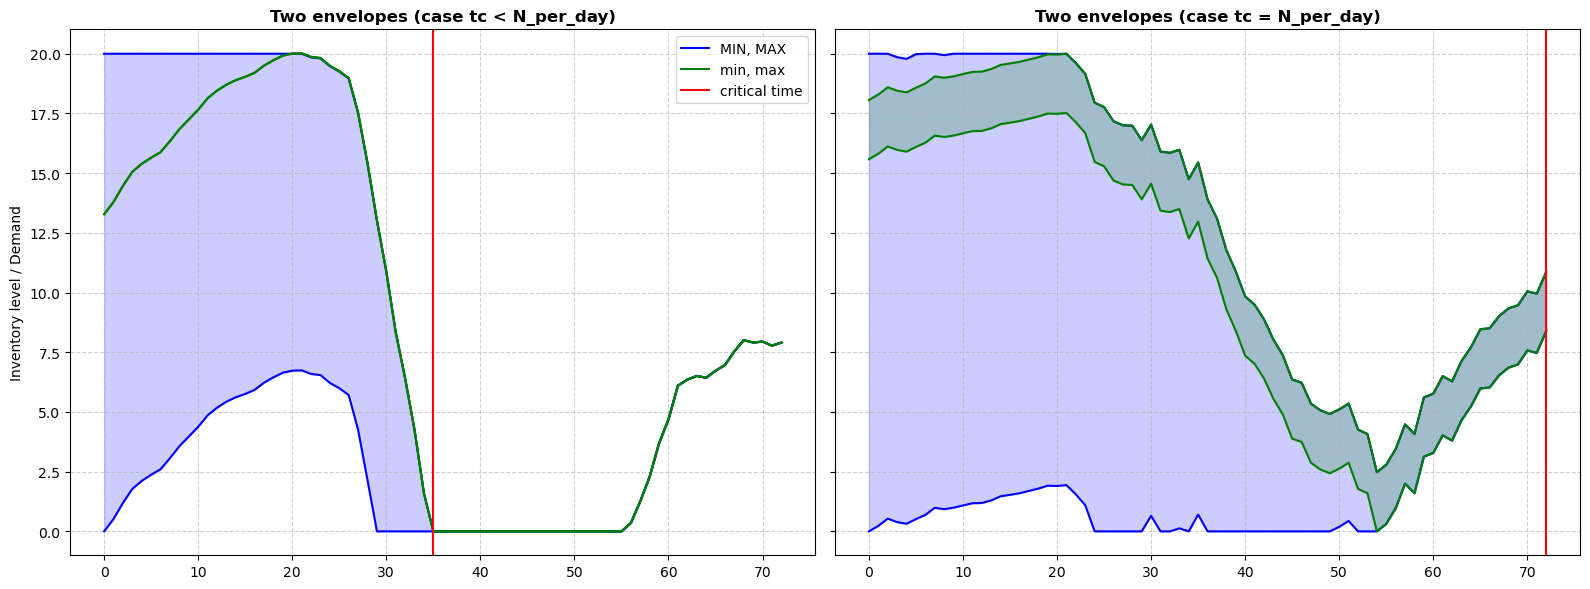

In [ ]:
configs = [
    (8, 1, "Two envelopes (case tc < N_per_day)"),
    (2, 1, "Two envelopes (case tc = N_per_day)")
]

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for i, (s, d, title) in enumerate(configs):

    ax = axes[i]

    # Blue envelope (MIN/MAX trajectories)
    ax.plot(times, xMIN[s, d], color="blue",
            label="MIN, MAX" if i == 0 else "")
    ax.plot(times, xMAX[s, d], color="blue")

    ax.fill_between(times, xMIN[s, d], xMAX[s, d],
                    color="blue", alpha=0.2)

    # Green envelope (balanced trajectories)
    ax.plot(times, xmin[s, d], color="green",
            label="min, max" if i == 0 else "")
    ax.plot(times, xmax[s, d], color="green")

    ax.fill_between(times, xmin[s, d], xmax[s, d],
                    color="green", alpha=0.2)

    # Critical time
    ax.axvline(x=tc[s, d], color="red",
               label="critical time" if i == 0 else "")

    # aesthetics
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.6)

    if i == 0:
        ax.set_ylabel("Inventory level / Demand")
        ax.legend()

plt.tight_layout()
plt.show()

### Motivation

The trajectory envelopes define the **envelope relation**.

For any trajectory and any time interval $[t_1, t_2]$ during which **no rebalancing occurs**, the inventory evolution satisfies

$$
x(t_2) = \Pi\left(x(t_1) + \Delta(t_2,t_1)\right)
$$

where

- $\Pi$ denotes the projection onto the feasible interval $[MIN, MAX]$,
- $\Delta(t_2,t_1)$ represents the variation of either envelope,  
  i.e. $x_{\max}(t_2) - x_{\max}(t_1)$ or $x_{\min}(t_2) - x_{\min}(t_1)$.

This envelope relation forms the basis of our **rebalancing oracle**:

planned rebalancing  
$\downarrow$  
predicted inventory  
$\downarrow$  
rebalancing score


---

### Remark

One may ask why we do not reason directly with **latent demand** for simulation.

The key advantage is that the **envelope relation is instantaneous**: it establishes a direct mapping

$$
\text{cause}(t_1) \rightarrow \text{consequence}(t_2)
$$

without explicitly considering intermediate time steps.

Otherwise, we would need to integrate the demand process over the entire interval $[t_1,t_2]$.

This property has two practical advantages.

**Prediction**

- it reduces error accumulation when demand is highly volatile.

**Storage and computation**

- only the time points of interest need to be stored.

For example, if the objective is to maintain a **balanced station at 12h00**, it is sufficient to store the envelopes at

- 00:00  (for initialisation with fictive candidate regulation)
- 12:00  
- 24:00  (for day to day transition relation $D \rightarrow D+1$ in multy days setting)

---

### (Optional) Extra Demand Stabilisation Step

**Remark.**  
In practice, one may want to perform a post-processing step on the envelopes in order to account for **demand friction**.

Friction is a common real-world phenomenon where station inventories tend to **plateau before reaching the exact bounds** (0 or 100% capacity).  
This may occur for instance due to **customer anticipation or behavioral effects**.

An illustration of this phenomenon is shown in "friction-manifestation.png".

---

### Demand Stabilisation Principle

Demand stabilisation consists in using a **reference stock observation** (the raw observed inventory trajectory) and stabilising the simulator trajectories as a post-processing step. We stabilise each of MIN, MAX, min, max simulated trajectory before storing them.

The stabilisation rule is the following:

Between two rebalancing actions (either **observed in the raw stock trajectory** or **simulated in the model**), trajectories are not allowed to cross.

If a simulated trajectory crosses the raw observed trajectory, the simulated trajectory is **collapsed onto the observed trajectory from the crossing time onward**.

An illustration of the stabilisation mechanism is shown in "stabilisation.png"